In [4]:
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import quad
from tqdm import tqdm
import math

In [3]:
def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel for 
    all combinations of training and test data.
    """
    
    # Compute the kernel matrices
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk')
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk')
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def compute_empirical_ntk(apply_fn, params, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel for
    all combinations of training and test data.
    """
    
    # Create a function that computes the empirical NTK
    ntk_fn = nt.empirical_ntk_fn(apply_fn, trace_axes=(-1,), vmap_axes=0, implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES)
   
    # Compute the kernel matrices
    ntk_train_train = ntk_fn(x_train, x_train, params)
    ntk_test_train  = ntk_fn(x_test, x_train, params)
    ntk_test_test   = ntk_fn(x_test, x_test, params)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def x_from_phi(phi):
    """Point on the circle, defined by angle phi."""
    return jnp.array([[jnp.cos(phi), jnp.sin(phi)]])

def kappa_phi(phi, kernel_fn):
    """
    Kernel profile κ(cos phi) = NTK(x(0), x(phi))
    This is used to integrate and get the eigenspectrum
    """
    # Reference point on the circle
    x0 = jnp.array([[1.0, 0.0]])  # θ = 0
    xt = x_from_phi(phi)
    val = kernel_fn(x0, xt, 'ntk')
    return float(jnp.asarray(val)[0, 0])

def lambda_k(k, kernel_fn, epsabs=1e-8, epsrel=1e-8):
    """
    Compute the k-th Fourier eigenvalue lambda_k on the circle
    """
    integrand = lambda phi: kappa_phi(phi, kernel_fn) * jnp.cos(k * phi)
    val, _ = quad(integrand, 0.0, jnp.pi,
                  epsabs=epsabs, epsrel=epsrel)
    return val / jnp.pi

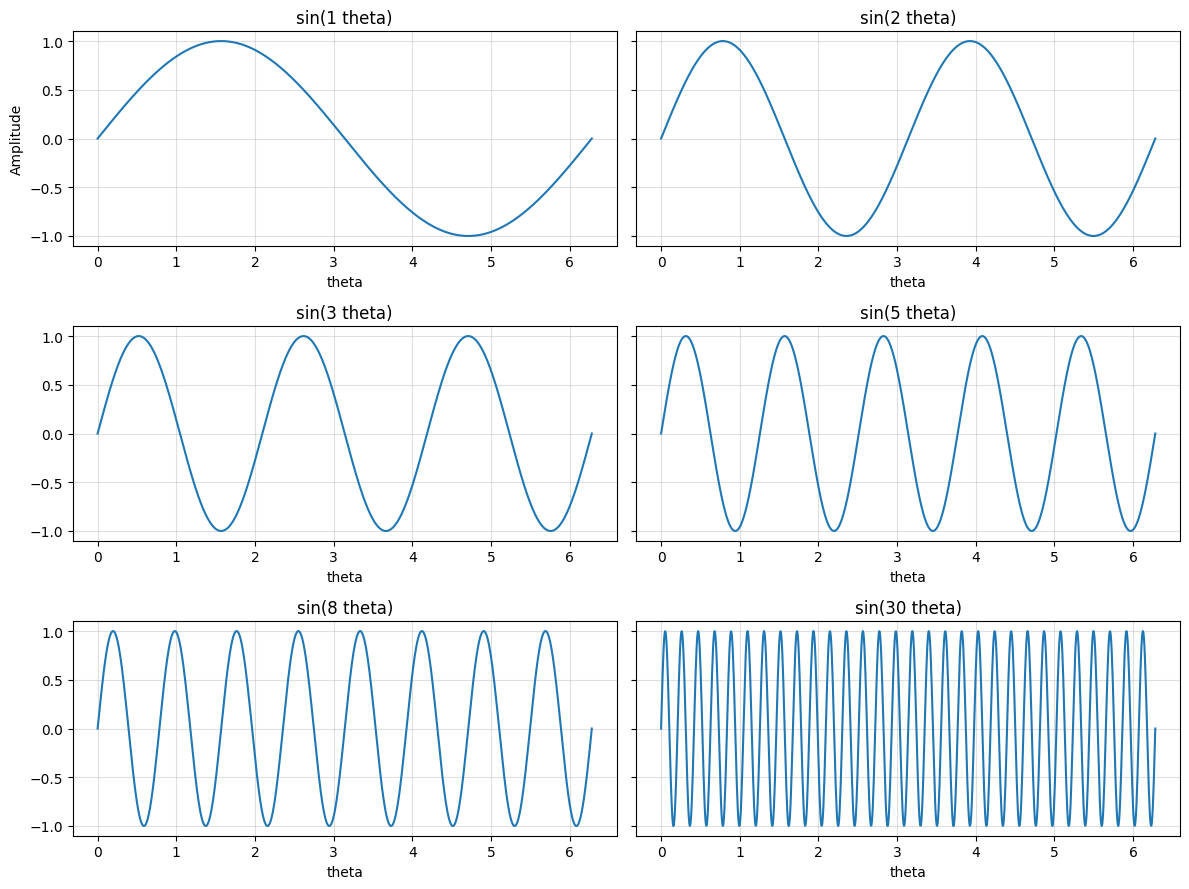

In [6]:
def plot_sin_k_theta_subplots(ks, n_points=1000):
    """
    Plot sin(k*theta) in separate subplots in a grid.
    """
    theta = jnp.linspace(0, 2*jnp.pi, n_points)
    num_plots = len(ks)

    ncols = 2
    nrows = math.ceil(num_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3*nrows), sharey=True)

    # Flatten axes for easy iteration
    axes = axes.flatten()

    for ax, k in zip(axes[:num_plots], ks):
        y = jnp.sin(k * theta)
        ax.plot(theta, y)
        ax.set_title(f"sin({k} theta)")
        ax.set_xlabel("theta")
        ax.grid(True, alpha=0.4)

    # Remove any unused subplots
    for ax in axes[num_plots:]:
        ax.remove()

    axes[0].set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# Some examples of target functions
plot_sin_k_theta_subplots([1, 2, 3, 5, 8, 30])


Reproduce the results in Bietti et al. (https://arxiv.org/pdf/1905.12173), points in unit circle, nonlinear regression (sin(k theta)) and zero biases.

/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, 0.0, jnp.pi,
/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(integrand, 0.0, jnp.pi,


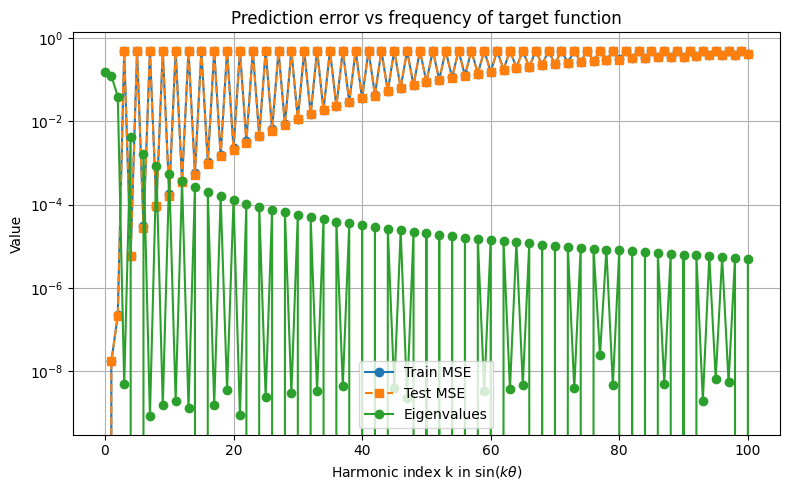

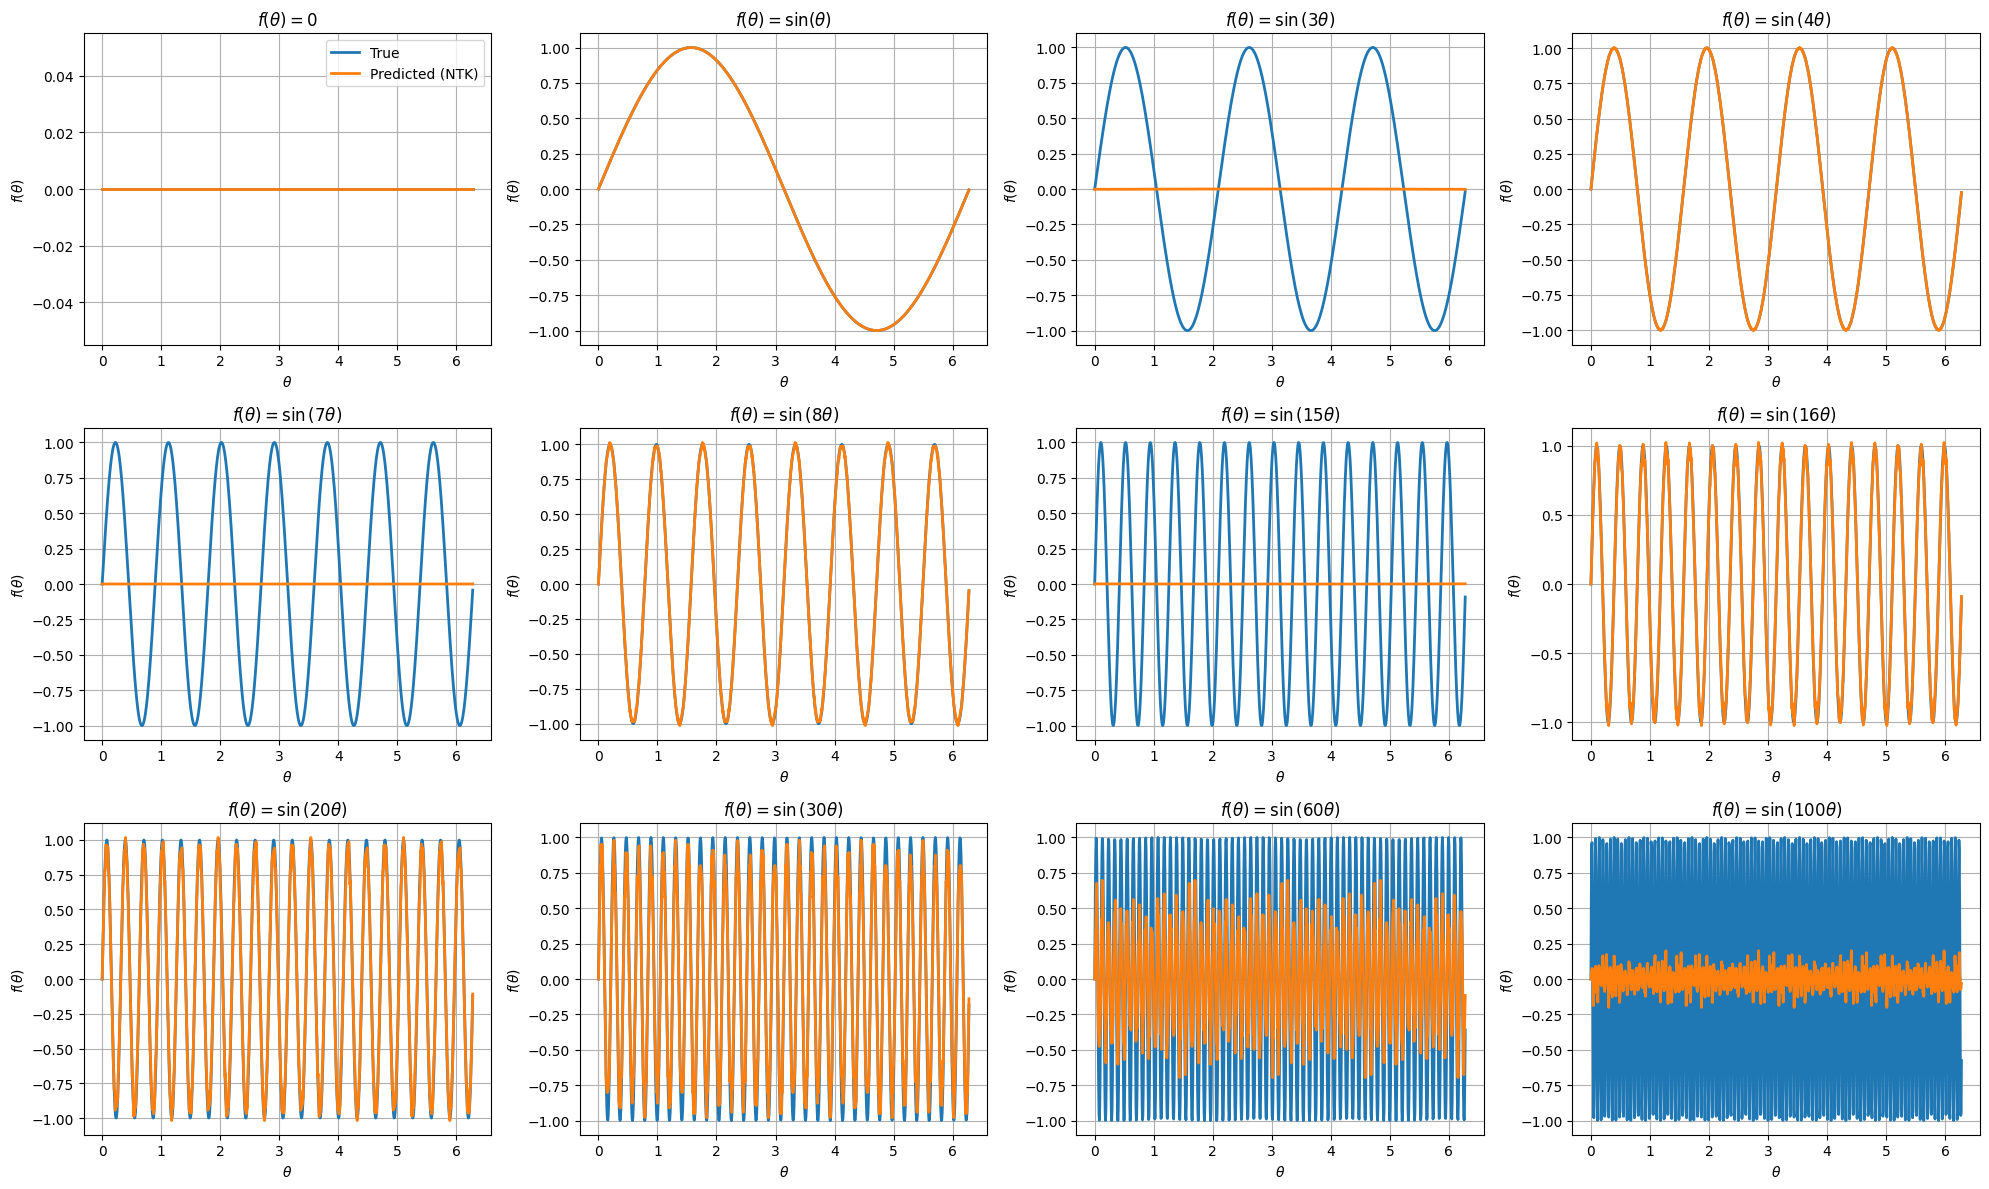

In [8]:
# Data creation
N_train = 2048
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1, b_std=0, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1, b_std=0, parameterization="ntk")
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

K_max = 100

lambda_vals = jnp.array([lambda_k(k, kernel_fn) for k in range(K_max + 1)])

# Kernel ridge regression on sin(kθ)
reg = 1e-2
K_reg = K_train + reg * jnp.eye(N_train)

train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 16, 20, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.plot(ks, train_mse, 'o-', label='Train MSE')
plt.plot(ks, test_mse,  's--', label='Test MSE')
plt.plot(ks, lambda_vals, 'o-', label="Eigenvalues")
plt.xlabel(r"Harmonic index k in $\sin(k \theta)$")
plt.ylabel("Value")
plt.title("Prediction error vs frequency of target function")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 4
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(20, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    if k==0:
        title=r"$f(\theta)=0$"
    elif k==1:
        title=r"$f(\theta)=\sin(\theta)$"
    else:
        title=fr"$f(\theta)=\sin$({k}$\theta$)"
    ax.set_title(title)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$f(\theta)$")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


Let's see what happens if the biases are not at zero.

/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, 0.0, jnp.pi,


/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(integrand, 0.0, jnp.pi,


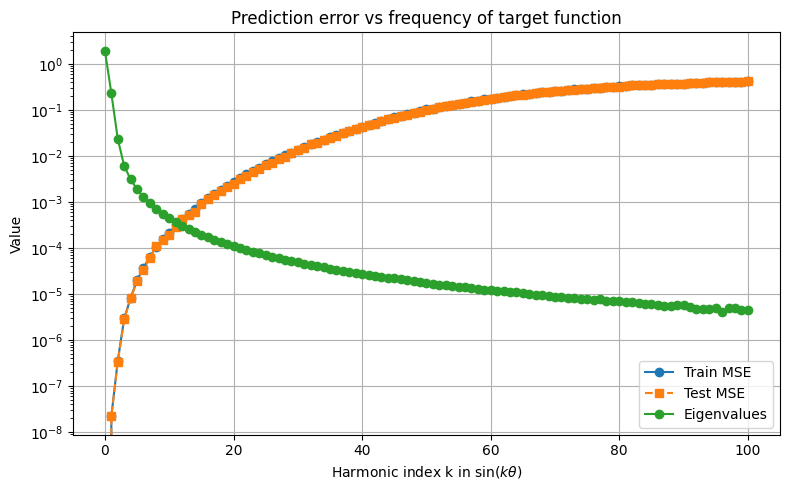

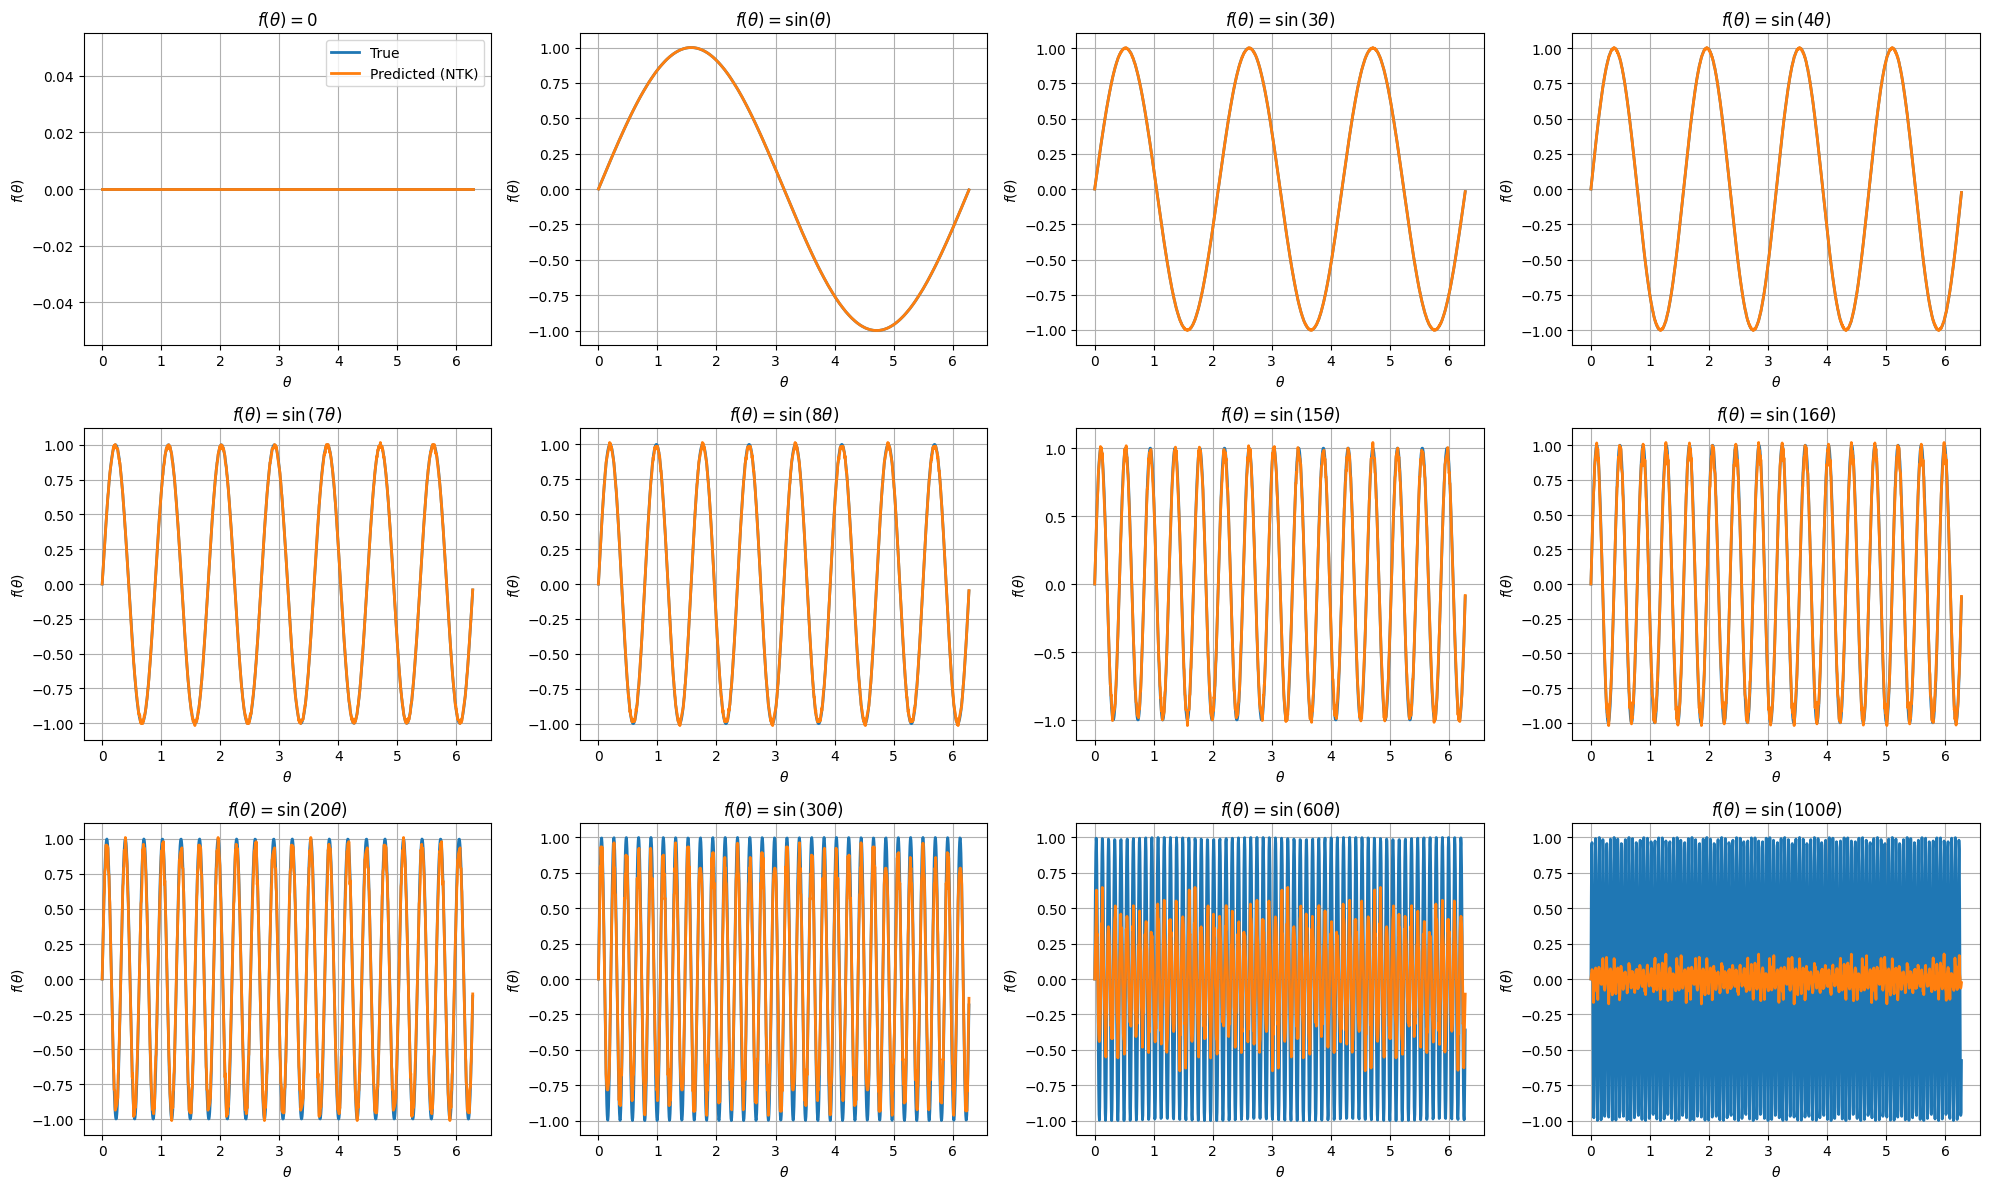

In [9]:
# Data creation
N_train = 2048
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1, b_std=1, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1, b_std=1, parameterization="ntk")
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

K_max = 100

lambda_vals = jnp.array([lambda_k(k, kernel_fn) for k in range(K_max + 1)])

# Kernel ridge regression on sin(kθ)
reg = 1e-2
K_reg = K_train + reg * jnp.eye(N_train)

train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 16, 20, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.plot(ks, train_mse, 'o-', label='Train MSE')
plt.plot(ks, test_mse,  's--', label='Test MSE')
plt.plot(ks, lambda_vals, 'o-', label="Eigenvalues")
plt.xlabel(r"Harmonic index k in $\sin(k \theta)$")
plt.ylabel("Value")
plt.title("Prediction error vs frequency of target function")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 4
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(20, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    if k==0:
        title=r"$f(\theta)=0$"
    elif k==1:
        title=r"$f(\theta)=\sin(\theta)$"
    else:
        title=fr"$f(\theta)=\sin$({k}$\theta$)"
    ax.set_title(title)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$f(\theta)$")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


It appears that the introduction of biases has increased the space of representable functions to the odd harmonics too. Let's see what happens if we use ONLY biases.

/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, 0.0, jnp.pi,
/tmp/ipykernel_1433776/539109282.py:58: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(integrand, 0.0, jnp.pi,


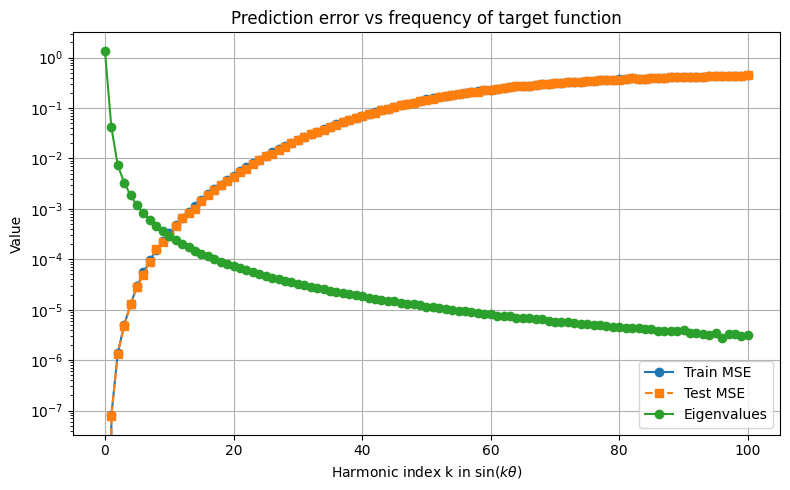

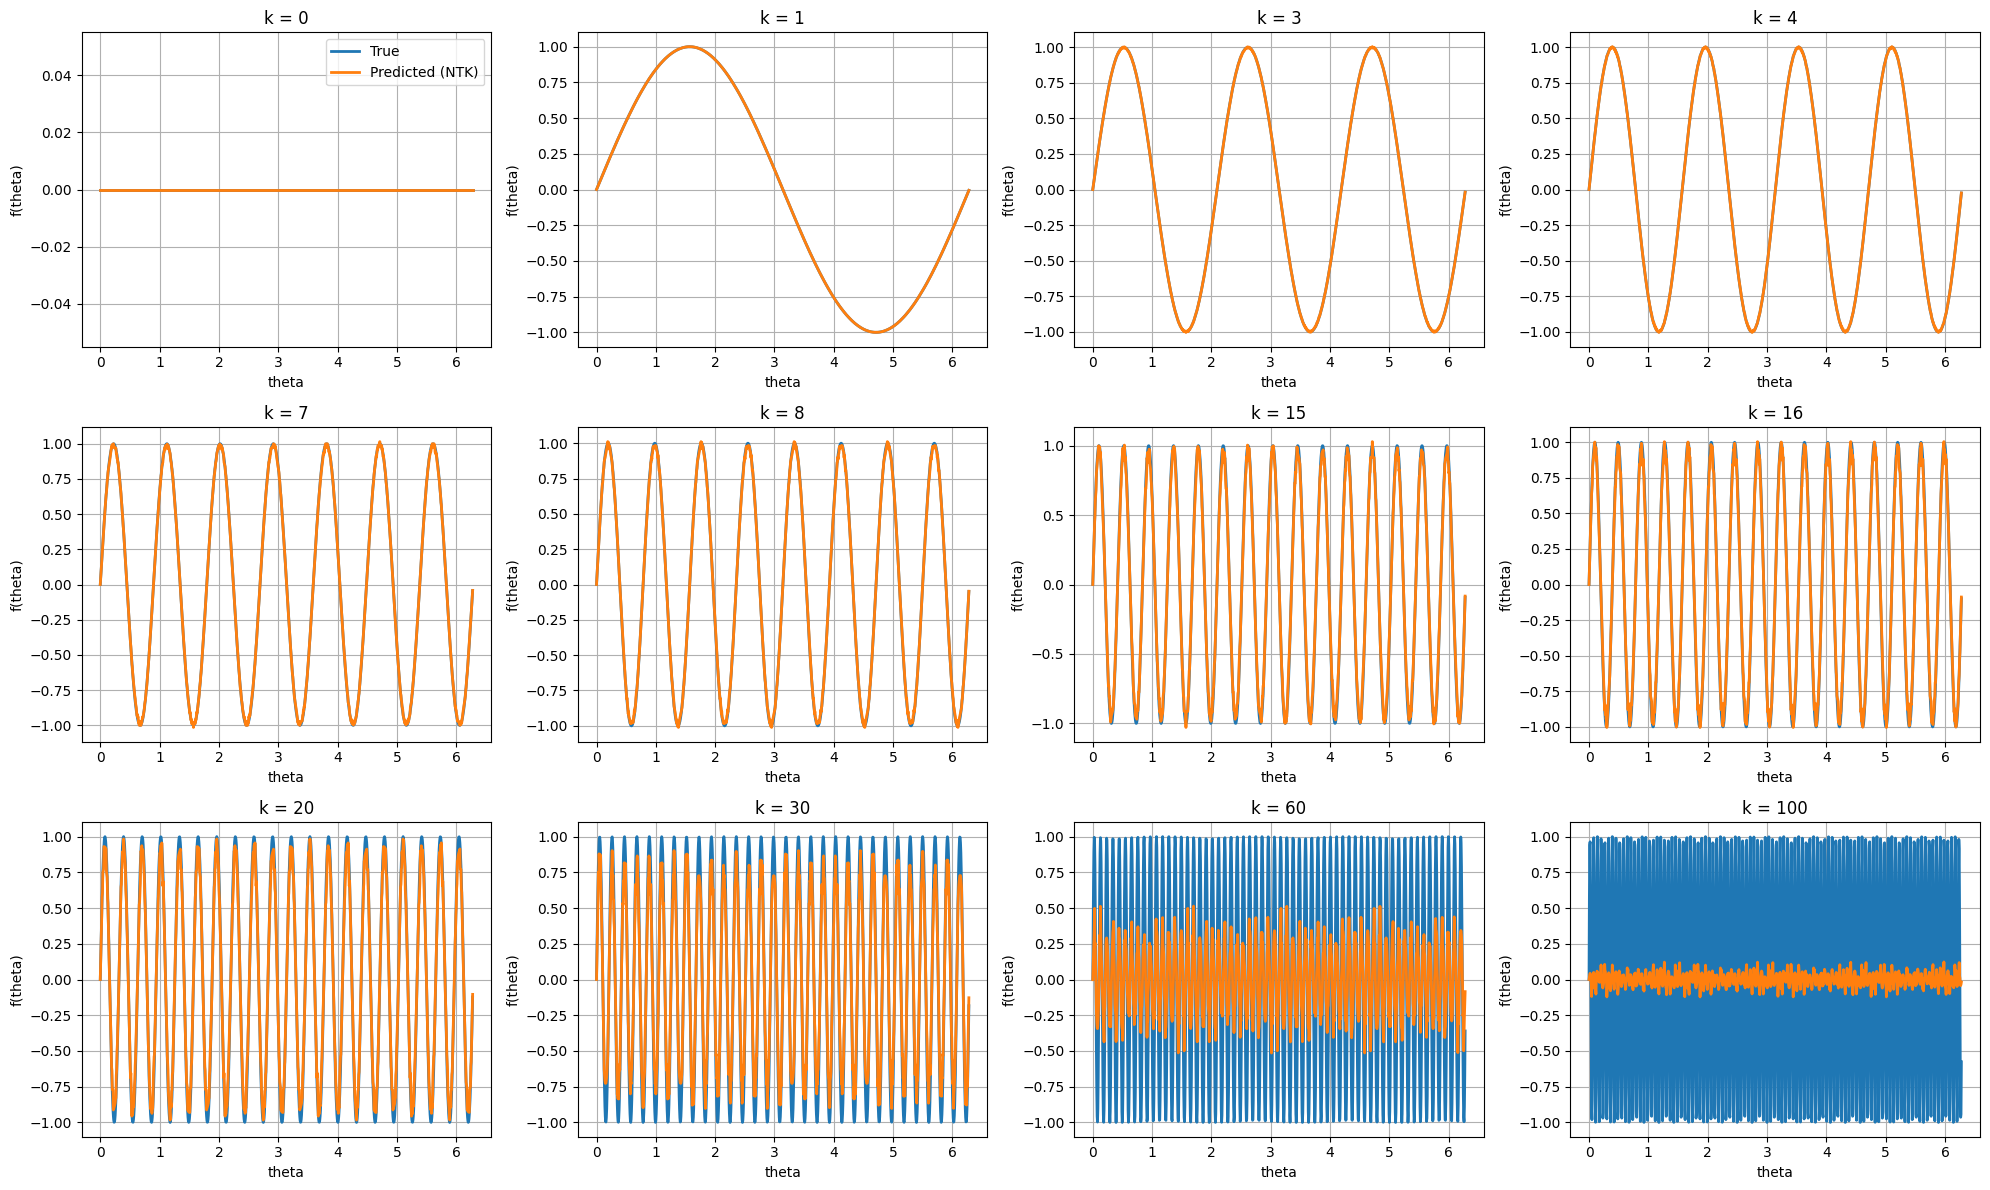

In [10]:
# Data creation
N_train = 2048
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1, b_std=1, parameterization="ntk", trainable=("b")),
    stax.Relu(),
    stax.Dense(1, W_std=1, b_std=1, parameterization="ntk", trainable=("b"))
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

K_max = 100

lambda_vals = jnp.array([lambda_k(k, kernel_fn) for k in range(K_max + 1)])

# Kernel ridge regression on sin(kθ)
reg = 1e-2
K_reg = K_train + reg * jnp.eye(N_train)

train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 16, 20, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.plot(ks, train_mse, 'o-', label='Train MSE')
plt.plot(ks, test_mse,  's--', label='Test MSE')
plt.plot(ks, lambda_vals, 'o-', label="Eigenvalues")
plt.xlabel(r"Harmonic index k in $\sin(k \theta)$")
plt.ylabel("Value")
plt.title("Prediction error vs frequency of target function")
plt.grid(True)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 4
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(20, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("theta")
    ax.set_ylabel("f(theta)")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


In [11]:
# Helper functions

def run_ntk_single(
    W_std=1.0,
    b_std=1.0,
    N_train=512,
    N_test=1024,
    K_max=100,
    reg=1,
    selected_ks=[0,1,3,4,7,8,15,30,60,100],
    trainable=("W","b")
):
    """Run NTK spectral + prediction experiment for one configuration."""

    # Generate data on S1
    angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
    angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

    X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
    X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test  = jnp.array(X_test,  dtype=jnp.float32)

    # Build NTK network
    init_fn, apply_fn, kernel_fn = stax.serial(
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
        stax.Relu(),
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable)
    )
    kernel_fn = nt.batch(kernel_fn, device_count=-1)

    # Compute eigenvalues
    X_full = jnp.array(jnp.column_stack([
        jnp.cos(jnp.linspace(0,2*jnp.pi,N_train)),
        jnp.sin(jnp.linspace(0,2*jnp.pi,N_train))
    ]), dtype=jnp.float32)

    K_ntk_full = jnp.array(kernel_fn(X_full, X_full, 'ntk'))
    eigvals = jnp.sort(jnp.linalg.eigvalsh(K_ntk_full))[::-1]

    # Kernel ridge regression for sin(kθ)
    K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
    K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))
    if reg=="auto":
        reg=eigvals[0]/300000
    K_reg = K_train + reg * jnp.eye(N_train)

    train_mse = []
    test_mse = []
    predictions = {}

    for k in range(K_max+1):
        y_train = jnp.sin(k * angles_train)
        y_test  = jnp.sin(k * angles_test)

        alpha = jnp.linalg.solve(K_reg, y_train)
        y_pred_train = K_train @ alpha
        y_pred_test  = K_test_train @ alpha

        train_mse.append(jnp.mean((y_pred_train - y_train)**2))
        test_mse.append(jnp.mean((y_pred_test - y_test)**2))

        if k in selected_ks:
            predictions[k] = dict(true=y_test, pred=y_pred_test)

    # Return full result object
    return dict(
    W_std=W_std,
    b_std=b_std,
    eigvals=jnp.array(eigvals),
    train_mse=jnp.array(train_mse),
    test_mse=jnp.array(test_mse),
    predictions=predictions,
    selected_ks=selected_ks,
    trainable=trainable,
    reg=reg
)

# Run multiple configs
def run_ntk_multiple(config_list):
    results = []
    for cfg in tqdm(config_list):
        res = run_ntk_single(**cfg)
        results.append(res)
    return results

# Plot eigenvalues
def plot_all_eigenspectra(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        trainable="both" if res['trainable']==("W","b") else "W" if res['trainable']==("W") else "b"
        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"
        plt.plot(res['eigvals'], label=label)

    plt.yscale("log")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("NTK Eigenvalue Spectra (multiple configs)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot MSE curves
def plot_all_mse_curves(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        trainable="both" if res['trainable']==("W","b") else "W" if res['trainable']==("W") else "b"
        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"
        #plt.semilogy(res['train_mse'], label=f"Train {label}")
        plt.semilogy(res['test_mse'], label=f"Test {label}")

    plt.xlabel("Harmonic index k")
    plt.ylabel("MSE (log scale)")
    plt.title("Prediction Error vs Frequency (multiple configs)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_mode_capacity(res, thresholds):
    """
    Return an array where entry i is the number of Fourier modes
    with test MSE < thresholds[i].
    """
    test_mse = res['test_mse']
    return jnp.array([jnp.sum(test_mse < t) for t in thresholds])


def compute_cutoff_frequency(res, threshold):
    """
    Return the maximum harmonic k such that test_mse[k] < threshold.
    Returns -1 if none are learnable.
    """
    test_mse = res['test_mse']
    below = jnp.where(test_mse < threshold)[0]
    return int(below.max()) if len(below) > 0 else -1

# Plot mode capacity
def plot_mode_capacity_multiple(all_results, 
                                thresholds=jnp.logspace(-6, 0, 50)):
    """
    Plot mode-learning capacity vs MSE threshold for multiple configs.
    
    Each curve = one NTK configuration.
    """

    plt.figure(figsize=(8,6))

    for res in all_results:

        trainable = ("both" if res['trainable']==("W","b") else
                     "W" if res['trainable']==("W") else
                     "b")

        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"

        capacities = compute_mode_capacity(res, thresholds)
        plt.plot(thresholds, capacities, label=label)

    plt.xscale("log")
    plt.xlabel("MSE threshold")
    plt.ylabel("# of learnable Fourier modes")
    plt.title("Learnable Bandwidth vs MSE Threshold")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_conditioning_before_after(all_results):
    plt.figure(figsize=(8,5))

    for i, res in enumerate(all_results):
        eig = res['eigvals']
        eig_pos = eig[eig > 0]

        if len(eig_pos) == 0:
            continue

        lam_max = float(eig_pos[0])
        lam_min = float(eig_pos[-1])
        reg     = float(res['reg'])

        cond_before = lam_max / lam_min
        cond_after  = (lam_max + reg) / (lam_min + reg)

        trainable = ("both" if res['trainable']==("W","b") else
                     "W"    if res['trainable']==("W")     else
                     "b")

        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}, reg={reg}"

        plt.scatter(i - 0.1, cond_before, color="blue",  label="before" if i==0 else None)
        plt.scatter(i + 0.1, cond_after,  color="red",   label="after"  if i==0 else None)

    plt.yscale("log")
    plt.xlabel("Trial index")
    plt.ylabel("Condition number")
    plt.title("Conditioning Before vs After Regularization")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Let's see how variations in W_std and b_std modify the results. First, set biases to 0 and change std of weights

100%|██████████| 7/7 [00:06<00:00,  1.09it/s]


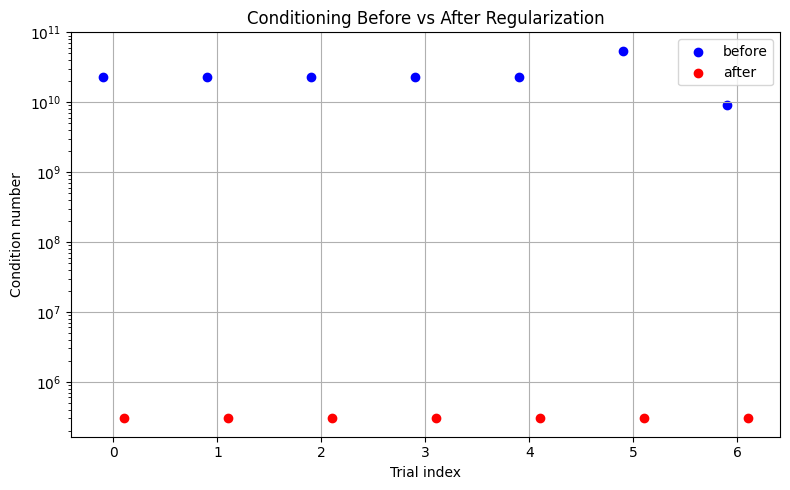

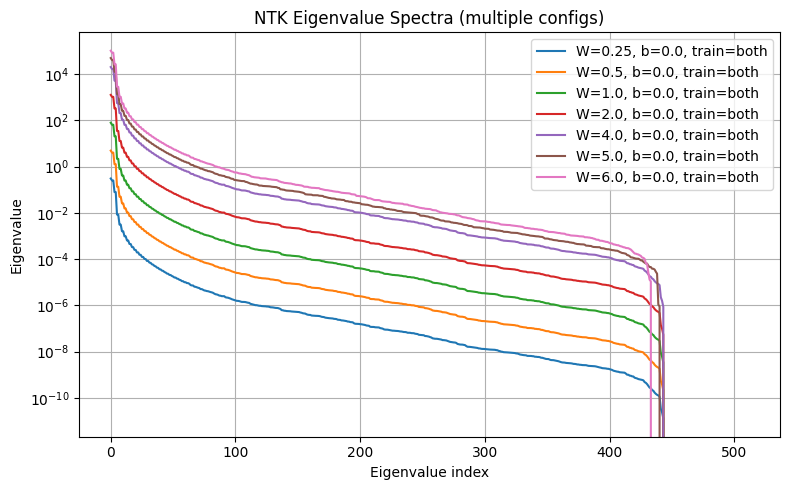

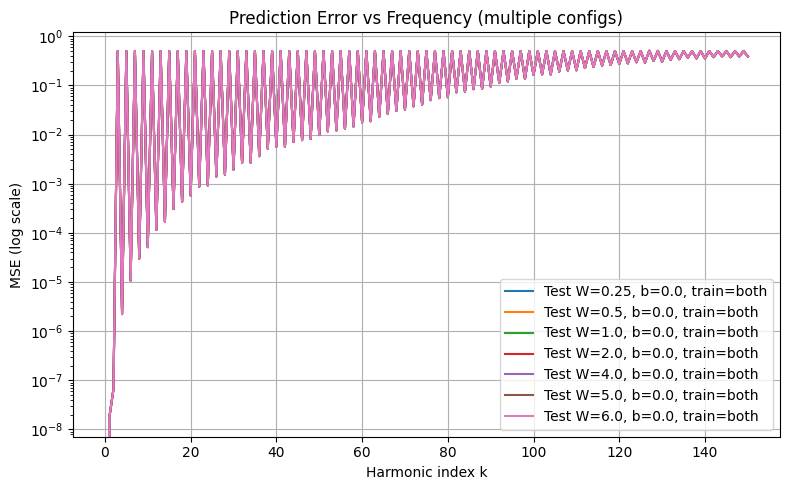

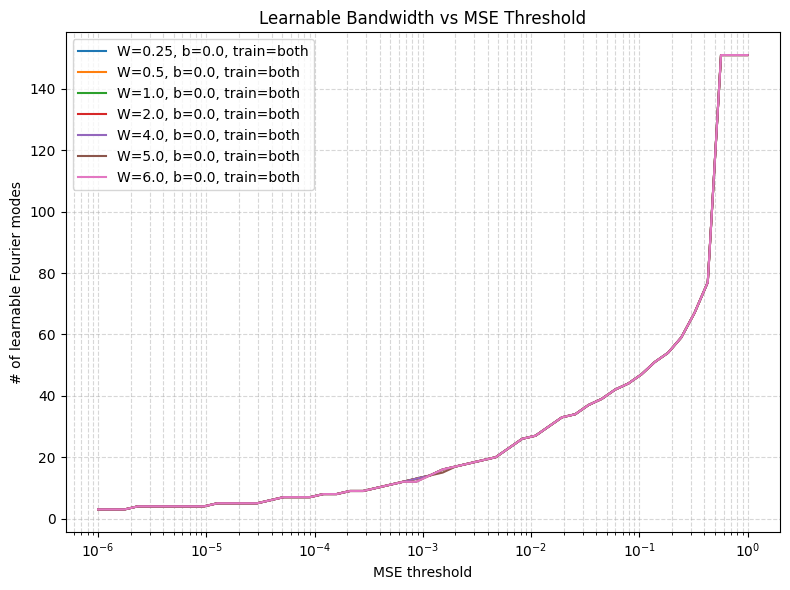

In [13]:
configs_W = [
    dict(W_std=0.25, b_std=0.0, reg="auto", K_max=150),
    dict(W_std=0.5,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=1.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=2.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=4.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=5.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=6.0,  b_std=0.0, reg="auto", K_max=150),
]

all_results = run_ntk_multiple(configs_W)

plot_conditioning_before_after(all_results)
plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

100%|██████████| 4/4 [00:02<00:00,  1.62it/s]


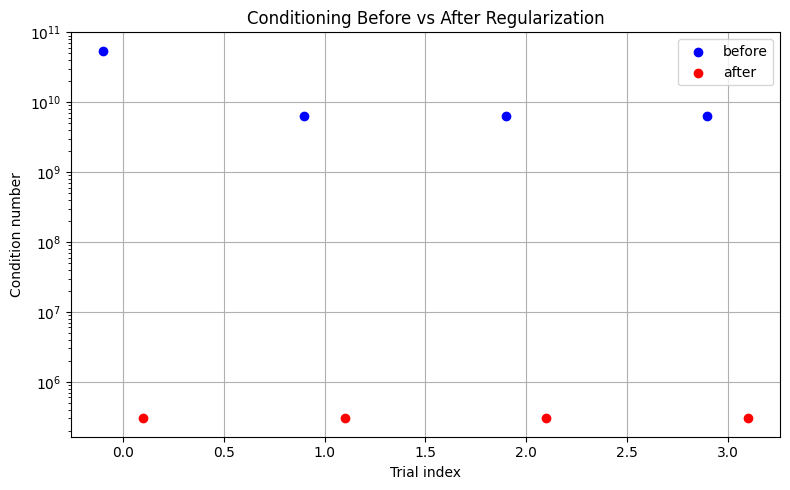

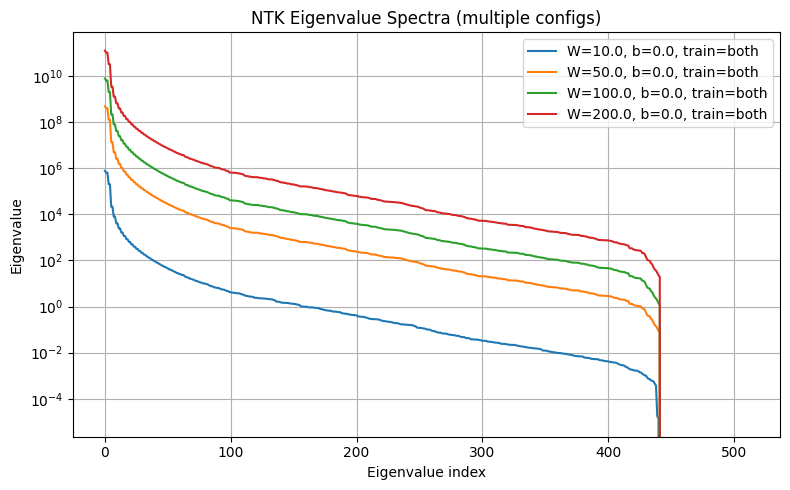

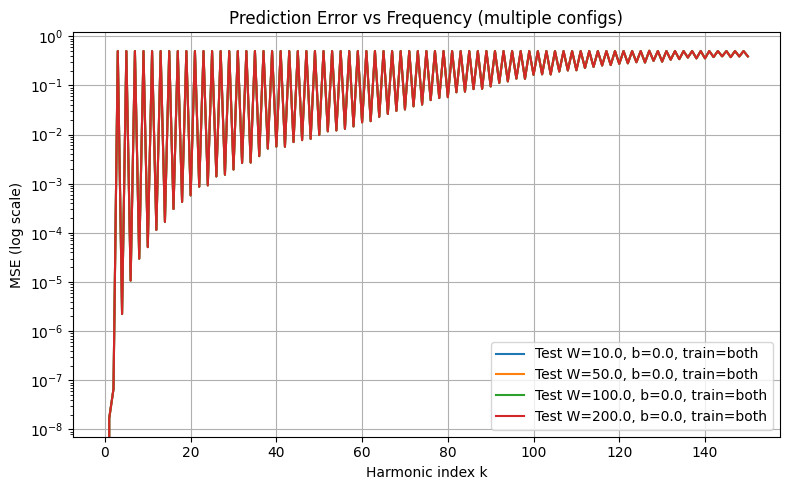

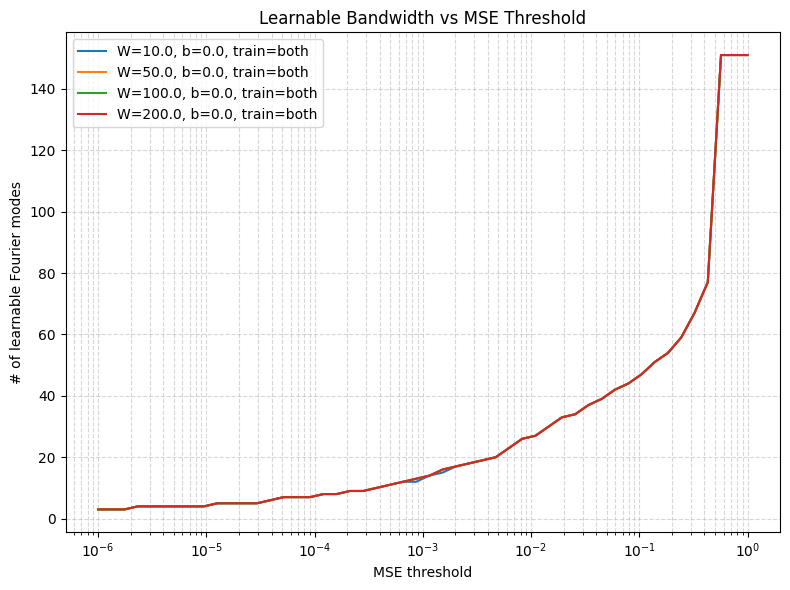

In [14]:
configs_W = [
    dict(W_std=10.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=50.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=100.0,  b_std=0.0, reg="auto", K_max=150),
    dict(W_std=200.0,  b_std=0.0, reg="auto", K_max=150),
]

all_results = run_ntk_multiple(configs_W)

plot_conditioning_before_after(all_results)
plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

The threshold smallest threshold needed to do K_max/2 tasks doesn't regress after W_std=6. Then, let's choose W_std=6.0 and change b_std.

100%|██████████| 9/9 [00:04<00:00,  1.85it/s]


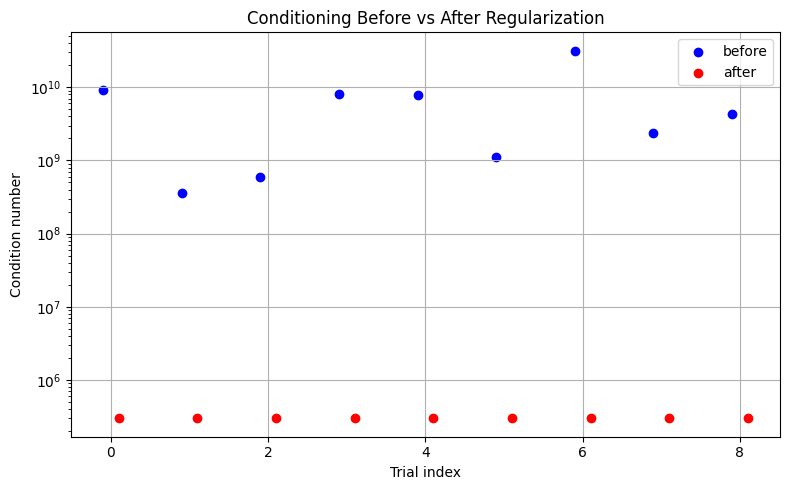

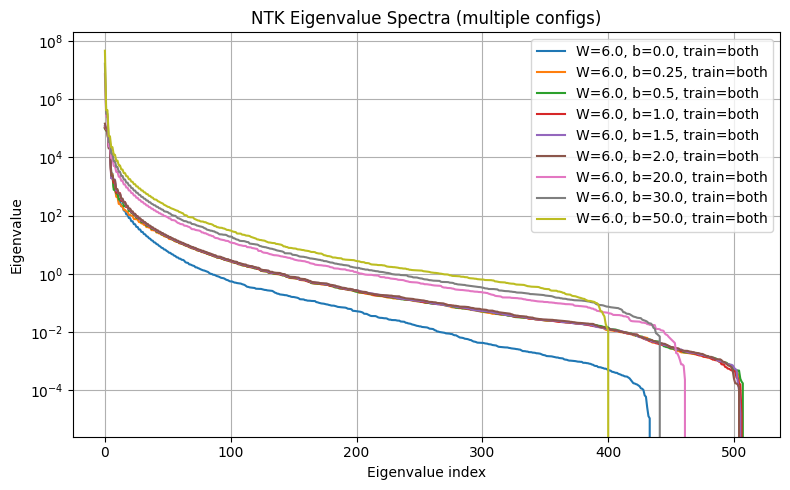

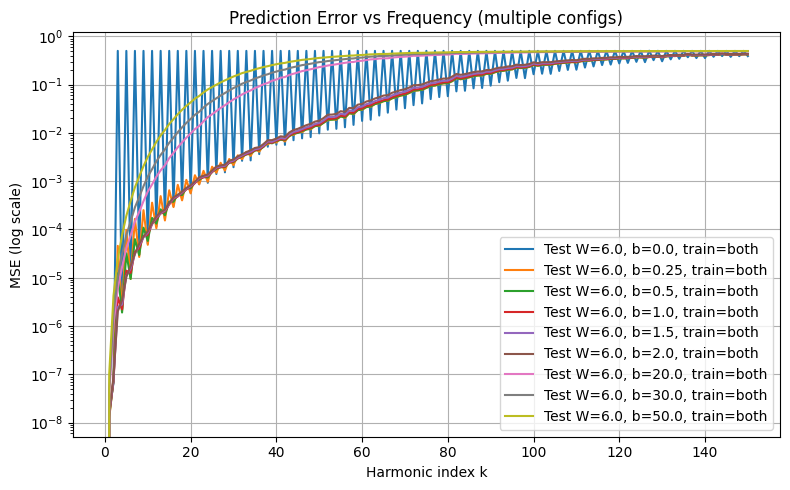

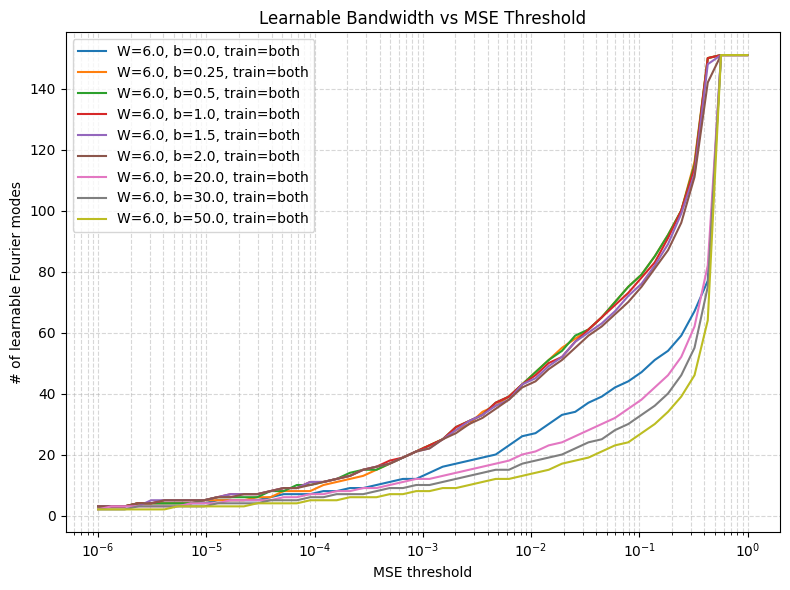

In [15]:
configs_b = [
    dict(W_std=6.0, b_std=0.0, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=0.25, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=0.5, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=1.0, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=1.5, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=2.0, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=20.0, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=30.0, reg="auto", K_max=150),
    dict(W_std=6.0, b_std=50.0, reg="auto", K_max=150),
]

all_results = run_ntk_multiple(configs_b)

plot_conditioning_before_after(all_results)
plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

Apparently, higher b_std help with the small odd eigenmodes but for the higher ones there's no difference between a low and a high b_std. Let's see if this applies also when we use the bias only ntk.

100%|██████████| 8/8 [00:04<00:00,  1.71it/s]


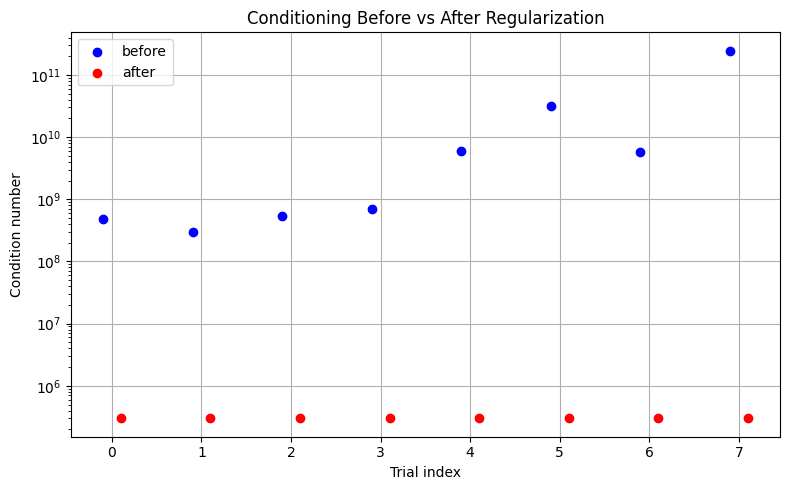

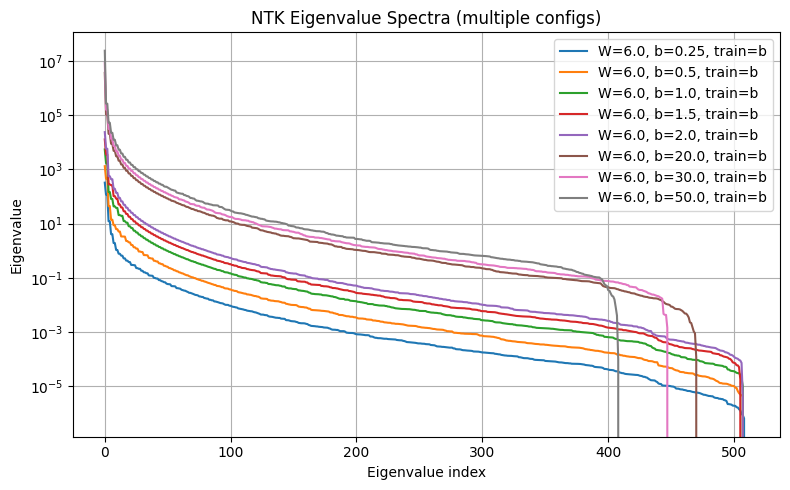

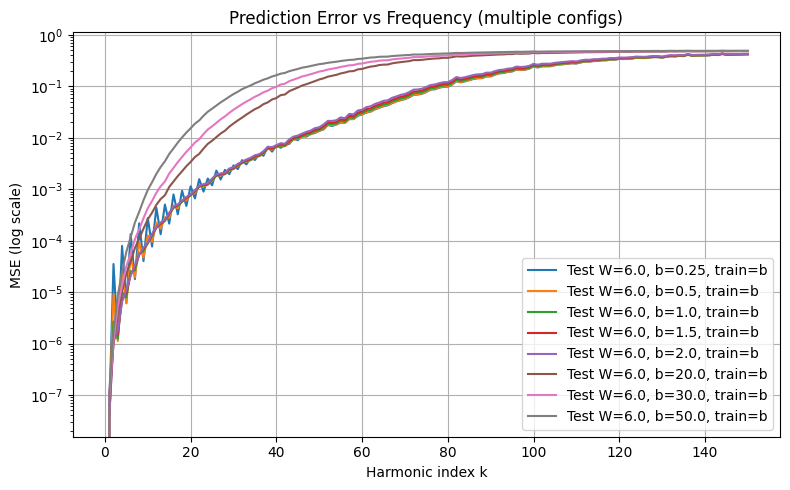

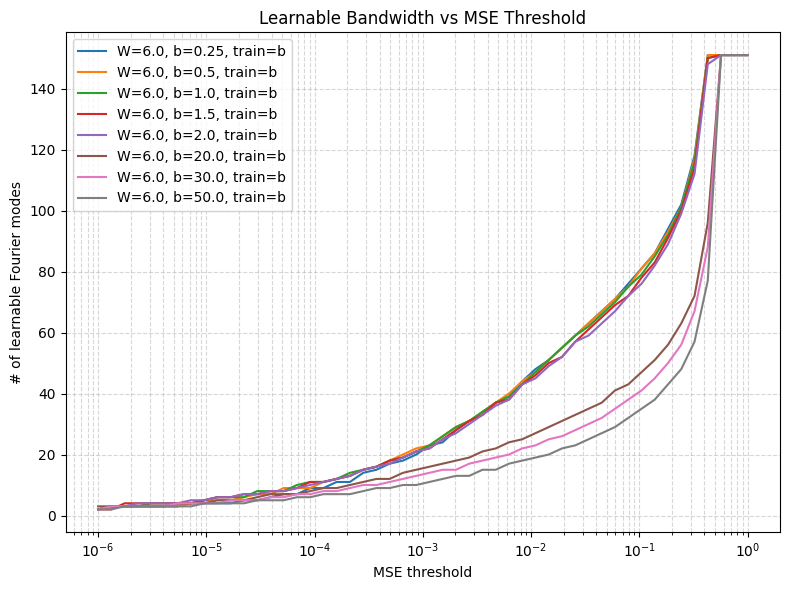

In [16]:
configs_b = [
    dict(W_std=6.0, b_std=0.25, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=0.5, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=1.0, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=1.5, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=2.0, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=20.0, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=30.0, reg="auto", K_max=150, trainable=("b")),
    dict(W_std=6.0, b_std=50.0, reg="auto", K_max=150, trainable=("b")),
]

all_results = run_ntk_multiple(configs_b)

plot_conditioning_before_after(all_results)
plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

It seems that b_std too big can be counterproductive. Also, it seems shrinking the b_std closes the gap in performance between bias only and full ntk, but also improves the performance of both. Let's visualize these differences.

In [20]:
def make_bstd_color_map(all_results):
    b_list = sorted({float(res['b_std']) for res in all_results})
    cmap = plt.cm.tab10
    return {b: cmap(i % 10) for i, b in enumerate(b_list)}

def plot_all_eigenspectra_grouped(all_results):
    plt.figure(figsize=(8,5))

    b_to_color = make_bstd_color_map(all_results)

    for res in all_results:
        b = float(res['b_std'])
        color = b_to_color[b]
        is_bias_only = (res["trainable"] == ("b",))
        style = "--" if is_bias_only else "-"

        label = (
            f"b_std={b} "
            + ("(bias only)" if is_bias_only else "(full)")
        )

        plt.plot(res["eigvals"], linestyle=style, color=color, label=label)

    plt.yscale("log")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("Eigenvalue Spectra: Full vs Bias-Only NTK")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_all_mse_curves_grouped(all_results):
    plt.figure(figsize=(8,5))

    b_to_color = make_bstd_color_map(all_results)

    for res in all_results:
        b = float(res['b_std'])
        color = b_to_color[b]
        is_bias_only = (res["trainable"] == ("b",))
        style = "--" if is_bias_only else "-"

        label = (
            f"b_std={b} "
            + ("(bias only)" if is_bias_only else "(full)")
        )

        plt.semilogy(res["test_mse"], linestyle=style, color=color, label=label)

    plt.xlabel("Harmonic index k")
    plt.ylabel("Test MSE (log)")
    plt.title("Prediction Error vs Frequency: Full vs Bias-Only NTK")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_mode_capacity_multiple_grouped(all_results,
                                        thresholds=jnp.logspace(-6, 0, 50)):
    plt.figure(figsize=(8,6))

    b_to_color = make_bstd_color_map(all_results)

    for res in all_results:
        b = float(res['b_std'])
        color = b_to_color[b]
        is_bias_only = (res["trainable"] == ("b",))
        style = "--" if is_bias_only else "-"

        label = (
            f"b_std={b} "
            + ("(bias only)" if is_bias_only else "(full)")
        )

        capacities = compute_mode_capacity(res, thresholds)
        plt.plot(thresholds, capacities, linestyle=style, color=color, label=label)

    plt.xscale("log")
    plt.xlabel("MSE threshold")
    plt.ylabel("# of learnable Fourier modes")
    plt.title("Bandwidth vs Threshold: Full vs Bias-Only NTK")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_mse_difference_full_vs_bias(all_results):
    plt.figure(figsize=(8,5))

    # get unique b_std values
    b_to_color = make_bstd_color_map(all_results)

    # group results by b_std
    grouped = {}
    for res in all_results:
        b = float(res['b_std'])
        grouped.setdefault(b, []).append(res)

    for b, group in grouped.items():
        # find full and bias-only pairs
        full = None
        bias = None
        for res in group:
            if res["trainable"] == ("b",):
                bias = res
            else:
                full = res

        if full is None or bias is None:
            continue  # skip if no complete pair

        color = b_to_color[b]

        mse_full = full["test_mse"]
        mse_bias = bias["test_mse"]

        mse_diff = mse_full - mse_bias

        plt.plot(mse_diff, color=color, label=f"b_std={b}")

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel("Harmonic index k")
    plt.ylabel("Δ MSE = MSE_full − MSE_bias")
    plt.title("Difference Between Full NTK and Bias-Only NTK (per b_std)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

100%|██████████| 14/14 [00:05<00:00,  2.40it/s]


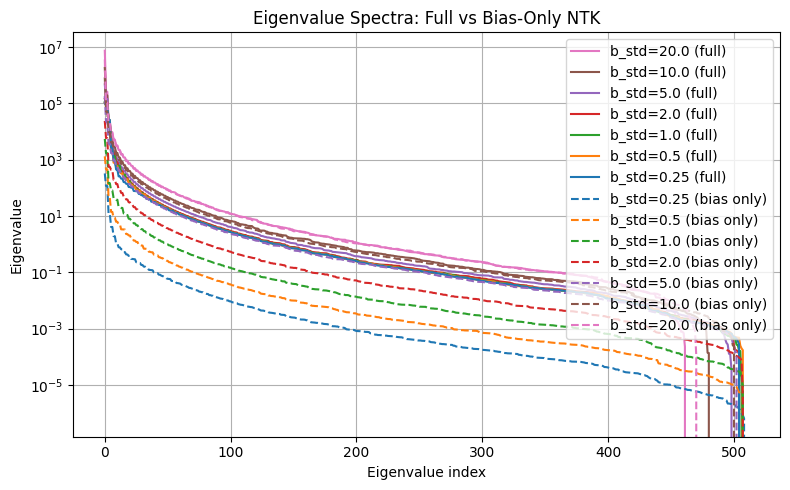

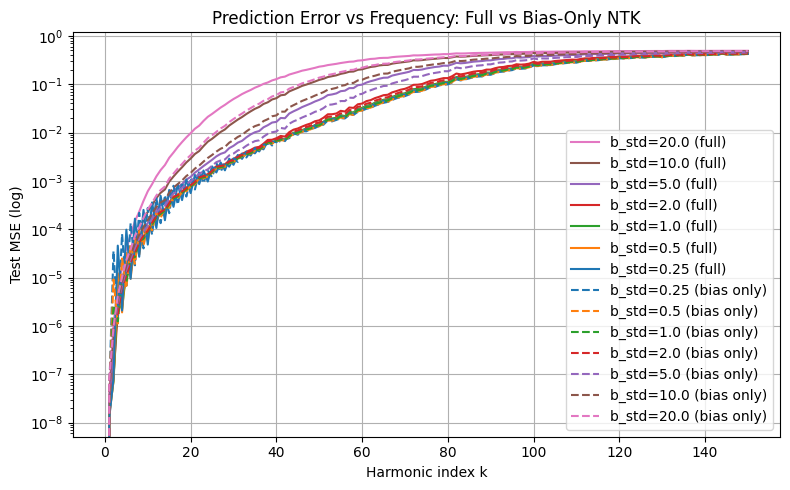

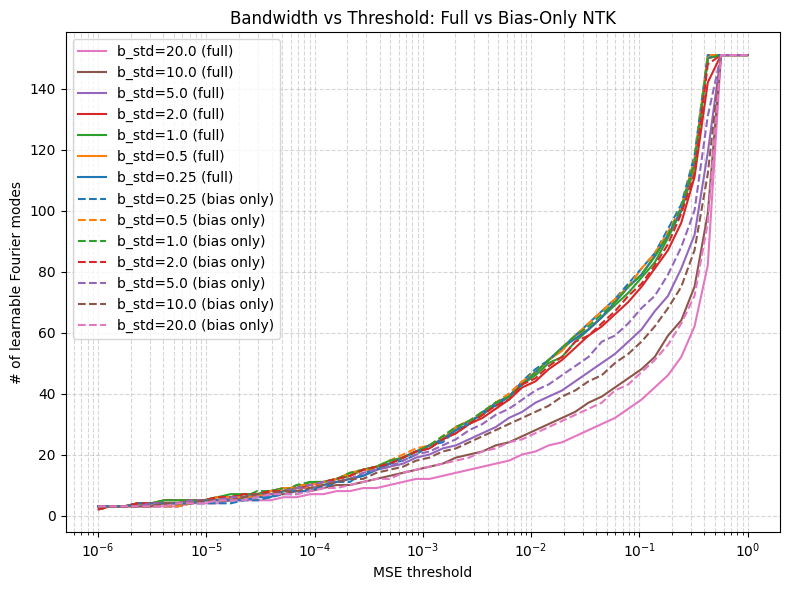

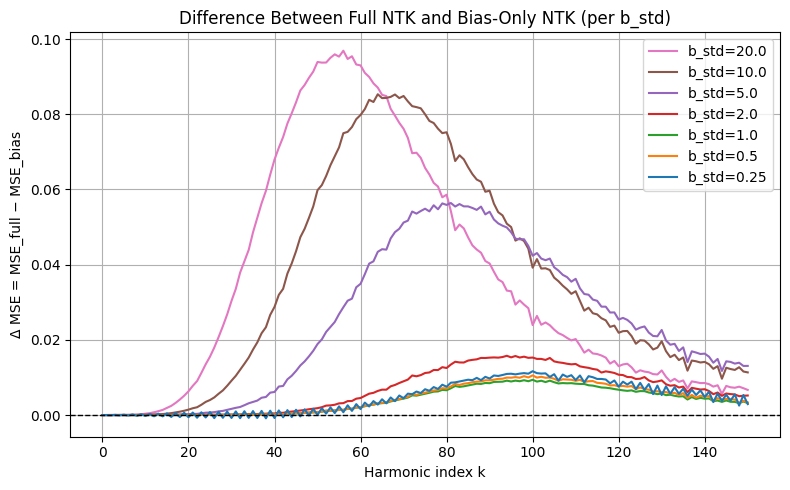

In [21]:
configs = [
    dict(W_std=6.0, b_std=20.0, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=10.0, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=5.0, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=2.0, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=1.0, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=0.5, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=0.25, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=0.25, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=0.5, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=1.0, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=2.0, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=5.0, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=10.0, K_max=150, reg="auto", trainable=("b",)),
    dict(W_std=6.0, b_std=20.0, K_max=150, reg="auto", trainable=("b",)),
]

all_results=run_ntk_multiple(configs)

plot_all_eigenspectra_grouped(all_results)
plot_all_mse_curves_grouped(all_results)
plot_mode_capacity_multiple_grouped(all_results)
plot_mse_difference_full_vs_bias(all_results)

So we can achieve the same performance as with the full ntk, with the bias only ntk.

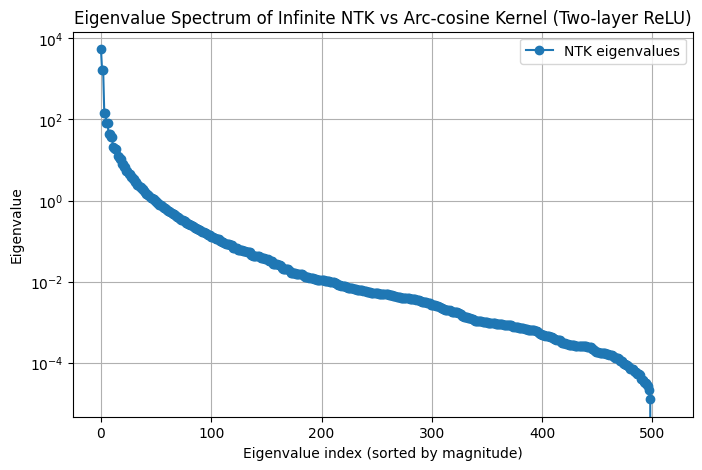

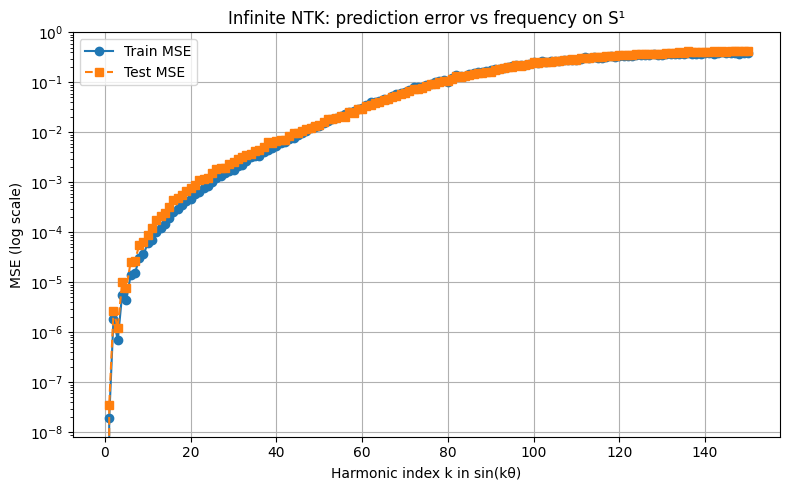

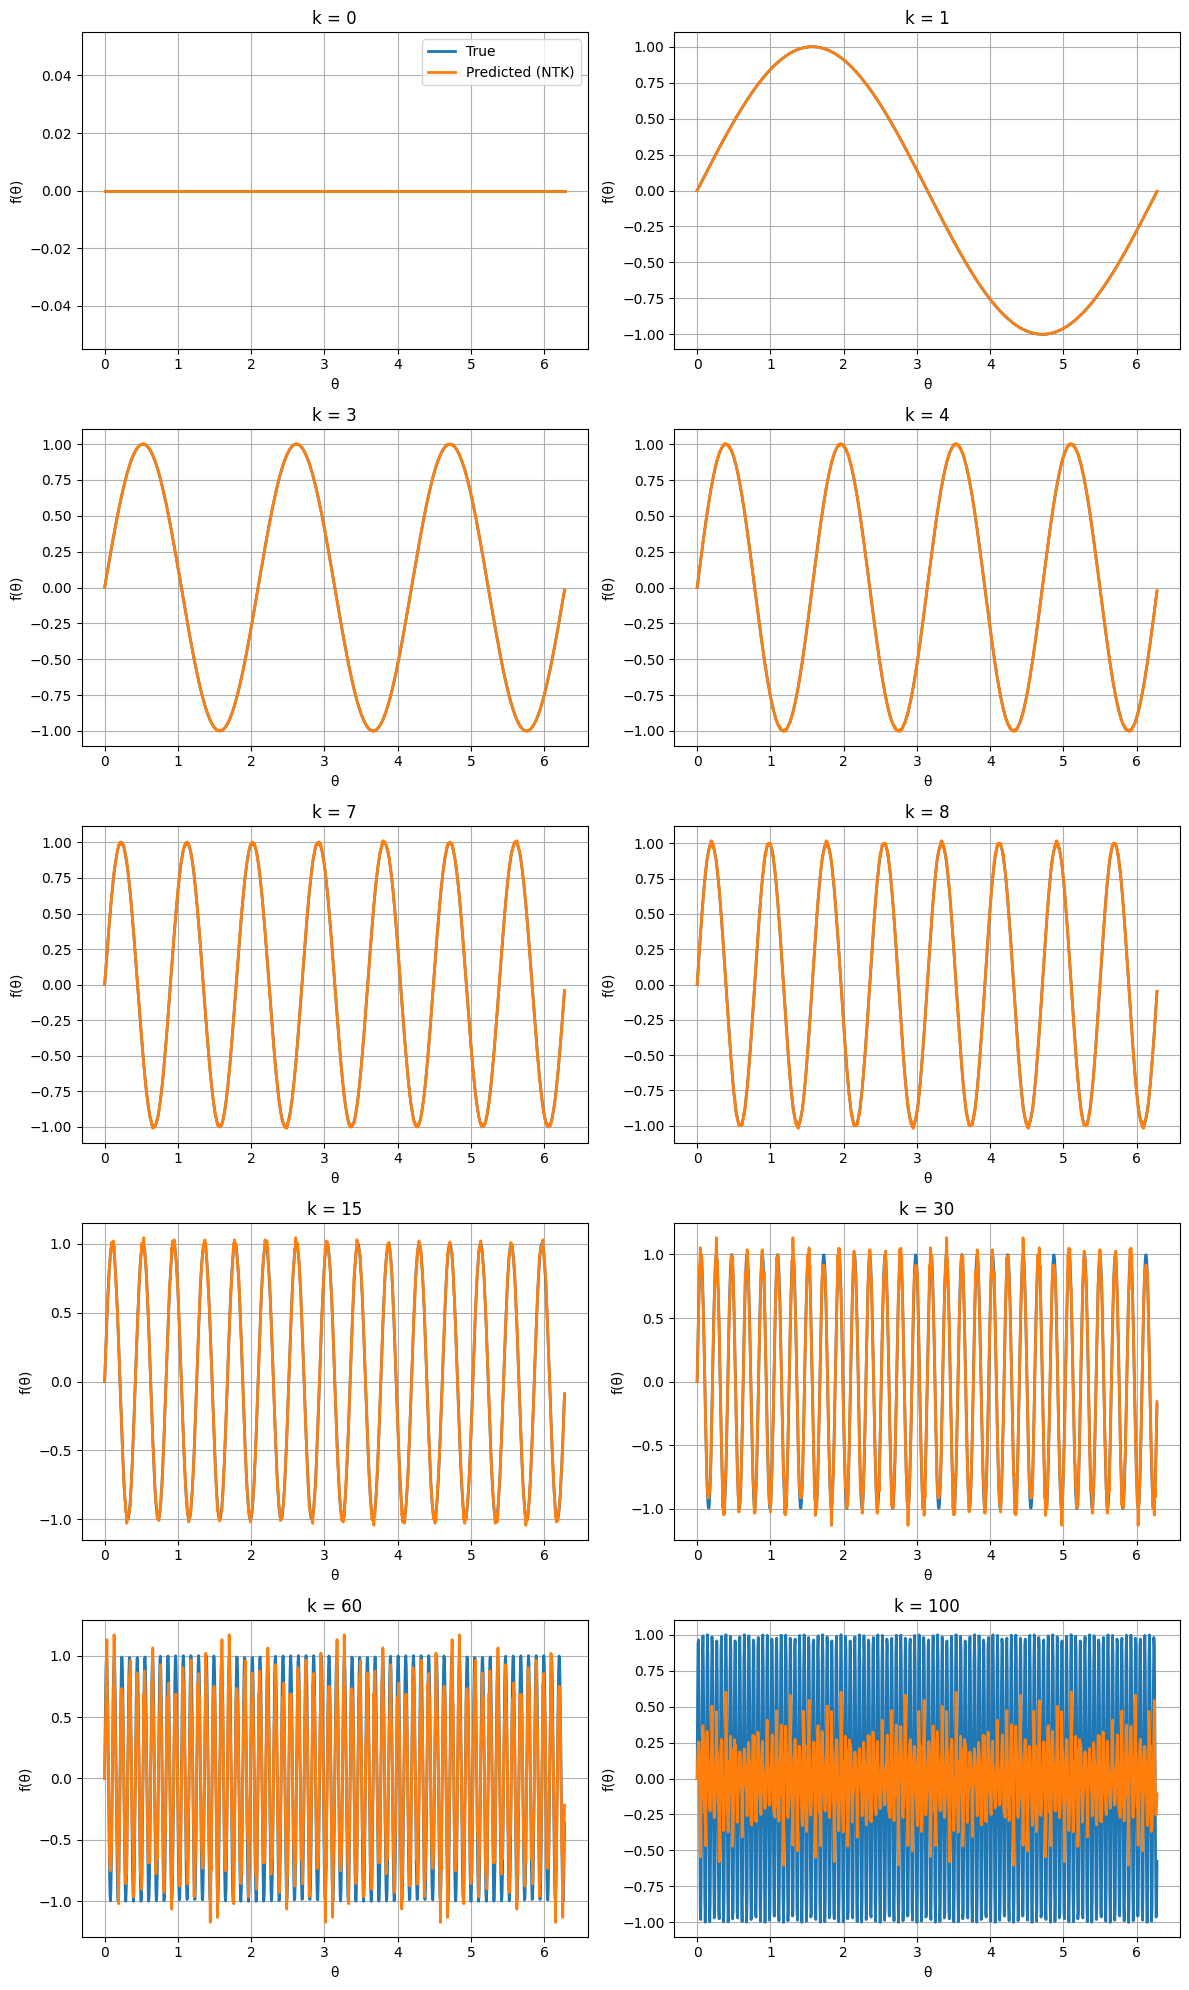

In [13]:
#Data creation
N_train = 512
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=6.0, b_std=1.0, parameterization="ntk", trainable=("b")),
    stax.Relu(),
    stax.Dense(1, W_std=6.0, b_std=1.0, parameterization="ntk", trainable=("b"))
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

# Do eigen-decomposition of the train kernel matrix
eigvals_ntk = jnp.linalg.eigvalsh(K_train)

# Sort eigenvalues for plotting.
eigvals_ntk = jnp.sort(eigvals_ntk)[::-1]

# Plot the eigenvalue spectrum.
plt.figure(figsize=(8,5))
plt.plot(eigvals_ntk, 'o-', label='NTK eigenvalues')
plt.yscale('log')
plt.xlabel("Eigenvalue index (sorted by magnitude)")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Infinite NTK vs Arc-cosine Kernel (Two-layer ReLU)")
plt.legend()
plt.grid(True)
plt.show()

# Kernel ridge regression on sin(kθ)
reg = eigvals_ntk[0]/300000
K_reg = K_train + reg * jnp.eye(N_train)

K_max = 150
train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.semilogy(ks, train_mse, 'o-', label='Train MSE')
plt.semilogy(ks, test_mse,  's--', label='Test MSE')
plt.xlabel("Harmonic index k in sin(kθ)")
plt.ylabel("MSE (log scale)")
plt.title("Infinite NTK: prediction error vs frequency on S¹")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 2
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(12, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("θ")
    ax.set_ylabel("f(θ)")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


However, another interesting fact happens. If we take a look at the performance of the full ntk against the one of the bias only, although the curves look very similar, we note that the "better" set of modes has been flipped, from the set of even modes to the set of odd ones. We can visualize this here:

100%|██████████| 2/2 [00:00<00:00,  2.25it/s]


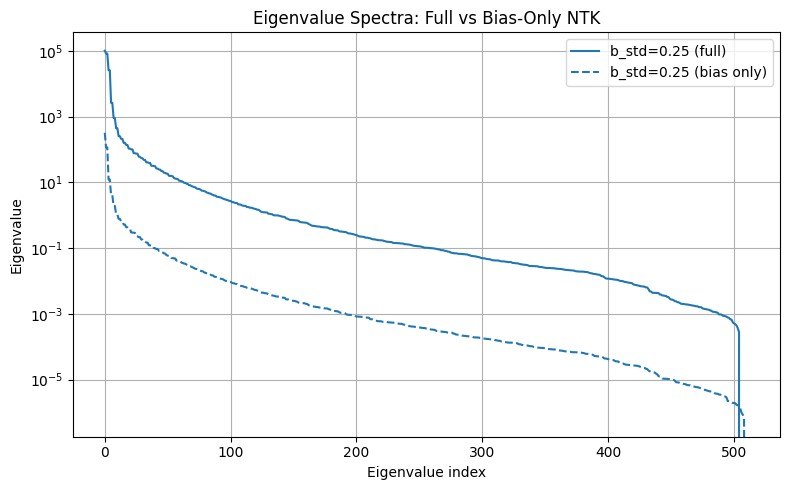

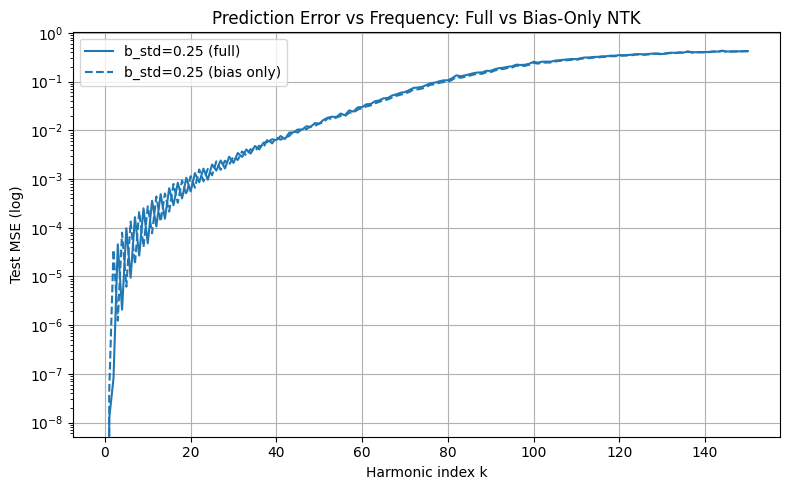

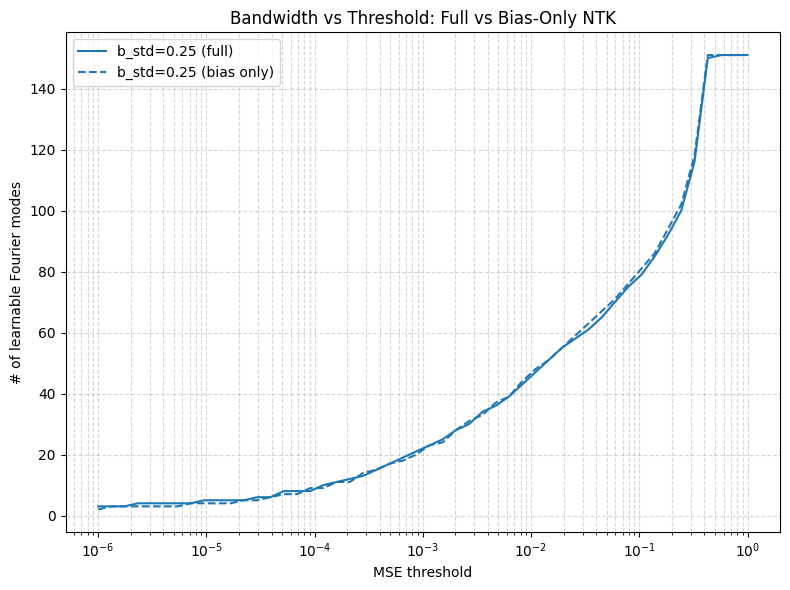

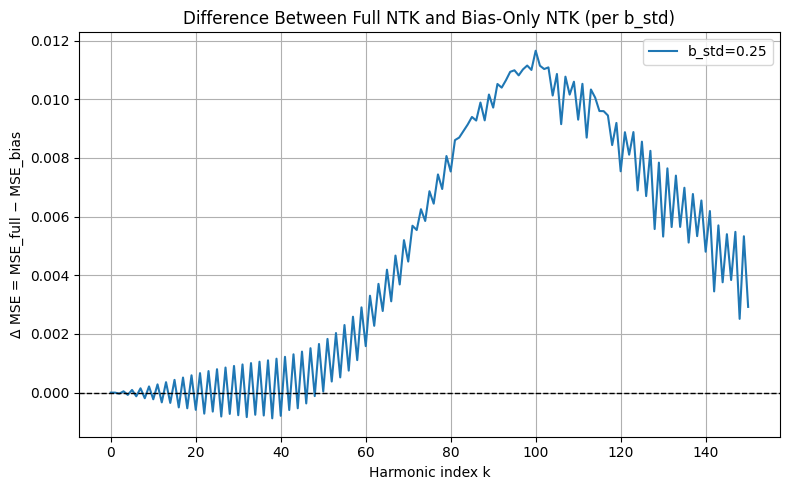

: 

In [ ]:
configs = [
    dict(W_std=6.0, b_std=0.25, K_max=150, reg="auto"),
    dict(W_std=6.0, b_std=0.25, K_max=150, reg="auto", trainable=("b",)),
]

all_results=run_ntk_multiple(configs)

plot_all_eigenspectra_grouped(all_results)
plot_all_mse_curves_grouped(all_results)
plot_mode_capacity_multiple_grouped(all_results)
plot_mse_difference_full_vs_bias(all_results)